# MMM Model Fitting

Fits a Bayesian Marketing Mix Model (geometric adstock + logistic saturation)
via pymc-marketing 1.0.0, and validates the fit against the true channel
parameters embedded in the synthetic dataset (see 01_data_generation).

**Note on environment:** pymc-marketing 1.0.0 requires adstock/saturation
transformer objects (not integer shorthand), and an explicit `target_column`
matching the actual DataFrame column name.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import arviz as az

df = pd.read_csv('../data/raw/mmm_weekly_data.csv', parse_dates=['date'])
contributions_true = pd.read_csv('../data/processed/true_contributions.csv')

channels = ['tv_spend', 'paid_search_spend', 'paid_social_spend', 'display_spend', 'promo_spend']

df.head()

,date,tv_spend,paid_search_spend,paid_social_spend,display_spend,promo_spend,price_index,sales
0,2022-01-03,8993.428306,7238.929413,5238.124523,1575.599082,3093.186627,1.008885,24155.655114
1,2022-01-10,7723.471398,5568.599505,5220.264454,1539.345407,988.784324,0.933233,29183.984268
2,2022-01-17,9295.377076,3570.435803,5958.218211,1779.958642,510.395180,1.019010,26079.531287
3,2022-01-24,11046.059713,5787.864330,4031.505762,158.463068,1374.213080,1.030529,26516.052515
4,2022-01-31,7531.693251,3830.381996,5022.929457,787.847150,1555.724912,1.027990,25932.639869


In [2]:
from pymc_marketing.mmm import MMM
from pymc_marketing.mmm.components.adstock import GeometricAdstock
from pymc_marketing.mmm.components.saturation import LogisticSaturation

mmm = MMM(
    date_column='date',
    channel_columns=channels,
    control_columns=['price_index'],
    adstock=GeometricAdstock(l_max=8),
    saturation=LogisticSaturation(),
    yearly_seasonality=2,
    target_column='sales',
)

X = df[['date'] + channels + ['price_index']]
y = df['sales']

mmm.fit(
    X, y.values,
    target_accept=0.98,
    chains=4,
    draws=1500,
    tune=1500,
    random_seed=42,
)

g++ not available, if using conda: `conda install gxx`
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [adstock_alpha, saturation_lam, saturation_beta, gamma_fourier, gamma_control, y_sigma, intercept_contribution]


Output()

Sampling 4 chains for 1_500 tune and 1_500 draw iterations (6_000 + 6_000 draws total) took 176 seconds.
There were 14 divergences after tuning. Increase `target_accept` or reparameterize.


Output()

<xarray.DataTree>
Group: /
│   Attributes: (12/24)
│       id:                         eebddbf57febc146
│       model_type:                 MMMM (Multi-Dimensional Marketing Mix Model)
│       version:                    0.0.2
│       sampler_config:             {}
│       model_config:               {"intercept": {"dist": "Normal", "kwargs": {"...
│       __serialization_version__:  1
│       ...                         ...
│       scaling:                    {"__type__": "pymc_marketing.mmm.scaling.Scal...
│       dag:                        null
│       treatment_nodes:            null
│       outcome_node:               null
│       mu_effects:                 []
│       cost_per_unit:              null
├── Group: /posterior
│       Dimensions:                                  (chain: 4, draw: 1500, channel: 5,
│                                                     fourier_mode: 4, control: 1,
│                                                     date: 156)
│       Coordinates:
│         * chain                                    (chain) int64 32B 0 1 2 3
│         * draw                                     (draw) int64 12kB 0 1 ... 1498 1499
│         * channel                                  (channel) <U17 340B 'tv_spend' ....
│         * fourier_mode                             (fourier_mode) <U5 80B 'sin_1' ....
│         * control                                  (control) <U11 44B 'price_index'
│         * date                                     (date) datetime64[us] 1kB 2022-0...
│       Data variables:
│           adstock_alpha                            (chain, draw, channel) float64 240kB ...
│           saturation_lam                           (chain, draw, channel) float64 240kB ...
│           saturation_beta                          (chain, draw, channel) float64 240kB ...
│           gamma_fourier                            (chain, draw, fourier_mode) float64 192kB ...
│           gamma_control                            (chain, draw, control) float64 48kB ...
│           y_sigma                                  (chain, draw) float64 48kB 0.061...
│           intercept_contribution                   (chain, draw) float64 48kB 0.942...
│           total_media_contribution_original_scale  (chain, draw) float64 48kB 4.061...
│           yearly_seasonality_contribution          (chain, draw, date) float64 7MB ...
│           fourier_contribution                     (chain, draw, date, fourier_mode) float64 30MB ...
│           control_contribution                     (chain, draw, date, control) float64 7MB ...
│           channel_contribution                     (chain, draw, date, channel) float64 37MB ...
│       Attributes:
│           created_at:                 2026-08-18T10:36:06.964119+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.3.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.1
│           sample_dims:                ['chain', 'draw']
│           sampling_time:              175.92982864379883
│           tuning_steps:               1500
│           pymc_marketing_version:     1.0.0
├── Group: /sample_stats
│       Dimensions:                (chain: 4, draw: 1500)
│       Coordinates:
│         * chain                  (chain) int64 32B 0 1 2 3
│         * draw                   (draw) int64 12kB 0 1 2 3 4 ... 1496 1497 1498 1499
│       Data variables: (12/18)
│           energy                 (chain, draw) float64 48kB -152.1 -154.7 ... -149.4
│           lp                     (chain, draw) float64 48kB 164.9 165.4 ... 161.5
│           tree_depth             (chain, draw) int64 48kB 9 9 9 9 9 9 ... 9 9 9 9 9 9
│           largest_eigval         (chain, draw) float64 48kB nan nan nan ... nan nan
│           reached_max_treedepth  (chain, draw) bool 6kB False False ... False False
│           diverging              (chain, draw) bool 6kB False False ... False Fa

In [3]:
pip install h5netcdf

Note: you may need to restart the kernel to use updated packages.


In [4]:
divergences = mmm.idata.sample_stats.diverging.sum().item()
print(f"Total divergences: {divergences}")

summary = az.summary(mmm.idata, var_names=['adstock_alpha', 'saturation_lam', 'saturation_beta', 'y_sigma'])
print(summary)

Total divergences: 14
                                       mean       sd eti89_lb eti89_ub ess_bulk ess_tail r_hat mcse_mean  mcse_sd
adstock_alpha[tv_spend]                0.62    0.236     0.16      0.9     1240     2083  1.00    0.0068   0.0044
adstock_alpha[paid_search_spend]       0.26    0.204     0.02     0.66     6427     3499  1.00    0.0025   0.0018
adstock_alpha[paid_social_spend]      0.348    0.233     0.03     0.75     4574     3239  1.00    0.0032   0.0017
adstock_alpha[display_spend]           0.58    0.325    0.053     0.95     1290     3140  1.00    0.0099   0.0038
adstock_alpha[promo_spend]             0.61    0.294    0.076     0.94     2221     3294  1.00    0.0065   0.0032
saturation_lam[tv_spend]                2.8        2     0.57      6.6     1664     1695  1.00     0.054    0.055
saturation_lam[paid_search_spend]       3.6     2.57     0.57      8.4     2429     2607  1.00     0.053    0.045
saturation_lam[paid_social_spend]      2.27      1.7     0.42     

In [5]:
mmm.idata.to_netcdf('../data/processed/mmm_fit.nc')
print("Saved.")

Saved.


In [6]:
print(list(mmm.idata.posterior.data_vars))

['adstock_alpha', 'saturation_lam', 'saturation_beta', 'gamma_fourier', 'gamma_control', 'y_sigma', 'intercept_contribution', 'total_media_contribution_original_scale', 'yearly_seasonality_contribution', 'fourier_contribution', 'control_contribution', 'channel_contribution']


In [7]:
print(mmm.idata)

<xarray.DataTree>
Group: /
│   Attributes: (12/24)
│       id:                         eebddbf57febc146
│       model_type:                 MMMM (Multi-Dimensional Marketing Mix Model)
│       version:                    0.0.2
│       sampler_config:             {}
│       model_config:               {"intercept": {"dist": "Normal", "kwargs": {"...
│       __serialization_version__:  1
│       ...                         ...
│       scaling:                    {"__type__": "pymc_marketing.mmm.scaling.Scal...
│       dag:                        null
│       treatment_nodes:            null
│       outcome_node:               null
│       mu_effects:                 []
│       cost_per_unit:              null
├── Group: /posterior
│       Dimensions:                                  (chain: 4, draw: 1500, channel: 5,
│                                                     fourier_mode: 4, control: 1,
│                                                     date: 156)
│       Coordinates:
│   

In [8]:
# Correct variable name: singular 'channel_contribution'
contributions_posterior = mmm.idata.posterior['channel_contribution'].mean(dim=['chain', 'draw'])

# Convert to DataFrame
contributions_estimated = contributions_posterior.to_pandas()
contributions_estimated.columns = channels

# Unscale back to original sales units using target_scale
target_scale = mmm.idata.constant_data['target_scale'].item()
contributions_estimated_original_scale = contributions_estimated * target_scale

print(f"Target scale factor: {target_scale:.2f}")
print(contributions_estimated_original_scale.shape)
contributions_estimated_original_scale.head()

Target scale factor: 45546.43
(156, 5)


,tv_spend,paid_search_spend,paid_social_spend,display_spend,promo_spend
date,,,,,
2022-01-03,5753.940713,3368.841592,1318.082770,947.022467,1586.194906
2022-01-10,7491.407383,3444.592475,1671.903181,1496.388586,1608.333076
2022-01-17,9030.341728,3104.102445,1939.835933,2017.212061,1480.048466
2022-01-24,10401.741405,3491.116867,1773.755637,1637.990380,1849.814235
2022-01-31,10522.235505,3202.009352,1899.025580,1784.520386,2175.641186


In [9]:
comparison = pd.DataFrame({
    'channel': channels,
    'true_total_contribution': [contributions_true[ch.replace('_spend','')].sum() for ch in channels],
    'estimated_total_contribution': contributions_estimated_original_scale.sum().values,
})
comparison['pct_difference'] = (
    (comparison['estimated_total_contribution'] - comparison['true_total_contribution'])
    / comparison['true_total_contribution'] * 100
)
comparison

,channel,true_total_contribution,estimated_total_contribution,pct_difference
0,tv_spend,240707.616558,1.673382e+06,595.192989
1,paid_search_spend,251240.351059,5.355706e+05,113.170621
2,paid_social_spend,182280.230824,2.639152e+05,44.785426
3,display_spend,56616.814498,5.471323e+05,866.377804
4,promo_spend,72378.017379,4.123685e+05,469.742786


In [10]:
contributions_posterior_raw = mmm.idata.posterior['channel_contribution'].mean(dim=['chain', 'draw'])
raw_df = contributions_posterior_raw.to_pandas()
raw_df.columns = channels
print(raw_df.describe())

         tv_spend  paid_search_spend  paid_social_spend  display_spend  \
count  156.000000         156.000000         156.000000     156.000000   
mean     0.235514           0.075377           0.037144       0.077004   
std      0.016312           0.004891           0.005922       0.010894   
min      0.126331           0.049032           0.019661       0.020792   
25%      0.228376           0.072271           0.033264       0.073711   
50%      0.236968           0.075899           0.037646       0.078386   
75%      0.245426           0.078507           0.041185       0.083351   
max      0.264241           0.088066           0.050426       0.097053   

       promo_spend  
count   156.000000  
mean      0.058037  
std       0.012009  
min       0.025613  
25%       0.050765  
50%       0.059094  
75%       0.065956  
max       0.083309  


In [11]:
import pymc_marketing.mmm as mmm_pkg
print([x for x in dir(mmm_pkg) if 'trend' in x.lower() or 'Trend' in x])

['LinearTrend', 'linear_trend']


In [12]:
import inspect
print(inspect.signature(MMM.__init__))

(self, *, date_column: 'str' = FieldInfo(annotation=NoneType, required=True, description='Column name of the date variable.'), channel_columns: 'list[str]' = FieldInfo(annotation=NoneType, required=True, description='Column names of the media channel variables.', metadata=[MinLen(min_length=1)]), target_column: 'str' = FieldInfo(annotation=NoneType, required=False, default='y', description='The name of the target column.'), adstock: 'InstanceOf[AdstockTransformation]' = FieldInfo(annotation=NoneType, required=True, description='Type of adstock transformation to apply.'), saturation: 'InstanceOf[SaturationTransformation]' = FieldInfo(annotation=NoneType, required=True, description='The saturation transformation to apply to the channel data.'), time_varying_intercept: "Annotated[StrictBool | InstanceOf[HSGPBase], Field(description='Whether to use a time-varying intercept, or pass an HSGP instance (e.g., SoftPlusHSGP) specifying dims and priors.')]" = False, time_varying_media: "Annotated

In [13]:
df['time_trend'] = np.arange(len(df)) / len(df)  # 0 to 1 linear trend over the full period

mmm = MMM(
    date_column='date',
    channel_columns=channels,
    control_columns=['price_index', 'time_trend'],
    adstock=GeometricAdstock(l_max=8),
    saturation=LogisticSaturation(),
    yearly_seasonality=2,
    target_column='sales',
)

X = df[['date'] + channels + ['price_index', 'time_trend']]
y = df['sales']

mmm.fit(
    X, y.values,
    target_accept=0.98,
    chains=4,
    draws=1500,
    tune=1500,
    random_seed=42,
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [adstock_alpha, saturation_lam, saturation_beta, gamma_fourier, gamma_control, y_sigma, intercept_contribution]


Output()

Sampling 4 chains for 1_500 tune and 1_500 draw iterations (6_000 + 6_000 draws total) took 203 seconds.
There were 34 divergences after tuning. Increase `target_accept` or reparameterize.


Output()

<xarray.DataTree>
Group: /
│   Attributes: (12/24)
│       id:                         eebddbf57febc146
│       model_type:                 MMMM (Multi-Dimensional Marketing Mix Model)
│       version:                    0.0.2
│       sampler_config:             {}
│       model_config:               {"intercept": {"dist": "Normal", "kwargs": {"...
│       __serialization_version__:  1
│       ...                         ...
│       scaling:                    {"__type__": "pymc_marketing.mmm.scaling.Scal...
│       dag:                        null
│       treatment_nodes:            null
│       outcome_node:               null
│       mu_effects:                 []
│       cost_per_unit:              null
├── Group: /posterior
│       Dimensions:                                  (chain: 4, draw: 1500, channel: 5,
│                                                     fourier_mode: 4, control: 2,
│                                                     date: 156)
│       Coordinates:
│         * chain                                    (chain) int64 32B 0 1 2 3
│         * draw                                     (draw) int64 12kB 0 1 ... 1498 1499
│         * channel                                  (channel) <U17 340B 'tv_spend' ....
│         * fourier_mode                             (fourier_mode) <U5 80B 'sin_1' ....
│         * control                                  (control) <U11 88B 'price_index'...
│         * date                                     (date) datetime64[us] 1kB 2022-0...
│       Data variables:
│           adstock_alpha                            (chain, draw, channel) float64 240kB ...
│           saturation_lam                           (chain, draw, channel) float64 240kB ...
│           saturation_beta                          (chain, draw, channel) float64 240kB ...
│           gamma_fourier                            (chain, draw, fourier_mode) float64 192kB ...
│           gamma_control                            (chain, draw, control) float64 96kB ...
│           y_sigma                                  (chain, draw) float64 48kB 0.042...
│           intercept_contribution                   (chain, draw) float64 48kB 1.204...
│           total_media_contribution_original_scale  (chain, draw) float64 48kB 1.783...
│           yearly_seasonality_contribution          (chain, draw, date) float64 7MB ...
│           fourier_contribution                     (chain, draw, date, fourier_mode) float64 30MB ...
│           control_contribution                     (chain, draw, date, control) float64 15MB ...
│           channel_contribution                     (chain, draw, date, channel) float64 37MB ...
│       Attributes:
│           created_at:                 2026-08-18T10:39:35.726199+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.3.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.1
│           sample_dims:                ['chain', 'draw']
│           sampling_time:              203.3878138065338
│           tuning_steps:               1500
│           pymc_marketing_version:     1.0.0
├── Group: /sample_stats
│       Dimensions:                (chain: 4, draw: 1500)
│       Coordinates:
│         * chain                  (chain) int64 32B 0 1 2 3
│         * draw                   (draw) int64 12kB 0 1 2 3 4 ... 1496 1497 1498 1499
│       Data variables: (12/18)
│           energy                 (chain, draw) float64 48kB -198.6 -192.1 ... -200.9
│           lp                     (chain, draw) float64 48kB 204.6 202.8 ... 209.8
│           tree_depth             (chain, draw) int64 48kB 10 10 10 10 ... 10 10 10 10
│           largest_eigval         (chain, draw) float64 48kB nan nan nan ... nan nan
│           reached_max_treedepth  (chain, draw) bool 6kB False False ... False False
│           diverging              (chain, draw) bool 6kB False False ... False

In [14]:
summary = az.summary(mmm.idata, var_names=['adstock_alpha', 'saturation_lam', 'saturation_beta', 'y_sigma'])
print(summary)

                                      mean       sd eti89_lb eti89_ub ess_bulk ess_tail r_hat mcse_mean  mcse_sd
adstock_alpha[tv_spend]              0.407    0.231    0.049     0.77     3397     3418  1.00    0.0039   0.0019
adstock_alpha[paid_search_spend]     0.372    0.249    0.031     0.78     3136     3246  1.00    0.0045   0.0021
adstock_alpha[paid_social_spend]     0.458    0.251    0.056     0.83     3696     3378  1.00    0.0041   0.0019
adstock_alpha[display_spend]         0.323    0.252    0.019      0.8     4501     2989  1.00    0.0038   0.0022
adstock_alpha[promo_spend]            0.51    0.305    0.045     0.92     2411     3404  1.00    0.0064   0.0025
saturation_lam[tv_spend]              3.58      2.4     0.62      8.1     2531     2460  1.00     0.048    0.038
saturation_lam[paid_search_spend]      4.1     2.61     0.69      8.8     1985     2283  1.00     0.056     0.04
saturation_lam[paid_social_spend]     2.86     2.05     0.52      6.7     3699     2679  1.00   

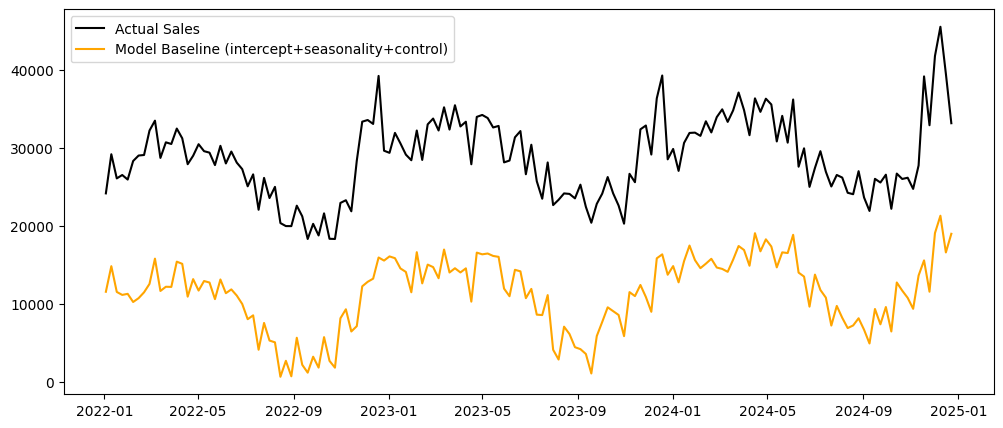

In [15]:
target_scale = mmm.idata.constant_data['target_scale'].item()

baseline_est = (
    mmm.idata.posterior['intercept_contribution'].mean(dim=['chain','draw']).item() +
    mmm.idata.posterior['yearly_seasonality_contribution'].mean(dim=['chain','draw']).values +
    mmm.idata.posterior['control_contribution'].mean(dim=['chain','draw']).sum(dim='control').values
) * target_scale

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df['date'], df['sales'], label='Actual Sales', color='black')
ax.plot(df['date'], baseline_est, label='Model Baseline (intercept+seasonality+control)', color='orange')
ax.legend()
plt.show()

In [16]:
contributions_posterior = mmm.idata.posterior['channel_contribution'].mean(dim=['chain', 'draw'])
contributions_estimated = contributions_posterior.to_pandas()
contributions_estimated.columns = channels
contributions_estimated_original_scale = contributions_estimated * target_scale

comparison = pd.DataFrame({
    'channel': channels,
    'true_total_contribution': [contributions_true[ch.replace('_spend','')].sum() for ch in channels],
    'estimated_total_contribution': contributions_estimated_original_scale.sum().values,
})
comparison['pct_difference'] = (
    (comparison['estimated_total_contribution'] - comparison['true_total_contribution'])
    / comparison['true_total_contribution'] * 100
)
comparison

,channel,true_total_contribution,estimated_total_contribution,pct_difference
0,tv_spend,240707.616558,920962.685886,282.606375
1,paid_search_spend,251240.351059,951040.417683,278.538087
2,paid_social_spend,182280.230824,451886.782892,147.907730
3,display_spend,56616.814498,118832.779496,109.889554
4,promo_spend,72378.017379,272871.278015,277.008501


In [17]:
comparison['true_share_of_media'] = comparison['true_total_contribution'] / comparison['true_total_contribution'].sum()
comparison['estimated_share_of_media'] = comparison['estimated_total_contribution'] / comparison['estimated_total_contribution'].sum()
comparison[['channel', 'true_share_of_media', 'estimated_share_of_media']]

,channel,true_share_of_media,estimated_share_of_media
0,tv_spend,0.299677,0.339139
1,paid_search_spend,0.312790,0.350215
2,paid_social_spend,0.226936,0.166404
3,display_spend,0.070487,0.043759
4,promo_spend,0.090109,0.100483


In [18]:
spend_totals = df[[f'{ch}' for ch in channels]].sum()
spend_share = spend_totals / spend_totals.sum()

efficiency = pd.DataFrame({
    'channel': channels,
    'spend_share': spend_share.values,
    'contribution_share': comparison['estimated_share_of_media'].values,
})
efficiency['efficiency_index'] = efficiency['contribution_share'] / efficiency['spend_share']
efficiency.sort_values('efficiency_index', ascending=False)

,channel,spend_share,contribution_share,efficiency_index
1,paid_search_spend,0.249499,0.350215,1.403672
4,promo_spend,0.072248,0.100483,1.390803
0,tv_spend,0.383493,0.339139,0.884340
2,paid_social_spend,0.198065,0.166404,0.840151
3,display_spend,0.096695,0.043759,0.452552


In [19]:
comparison.to_csv('../data/processed/channel_comparison.csv', index=False)
efficiency.to_csv('../data/processed/channel_efficiency.csv', index=False)
print("Saved.")

Saved.
